In [1]:
import pandas as pd

games = pd.read_csv("chess_games.csv")
games.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


Task 1


In [2]:
games.dtypes

id                 object
rated                bool
created_at        float64
last_move_at      float64
turns               int64
victory_status     object
winner             object
increment_code     object
white_id           object
white_rating        int64
black_id           object
black_rating        int64
moves              object
opening_eco        object
opening_name       object
opening_ply         int64
dtype: object

In [3]:
games.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000


Numerical: white rating, black rating, turns
categorical: winner, victory_status, id
??? : increment_code (categorical?), questionable when number is a category

Task 2
Winner column data type: Ordinal categorical
Bar chart for small set of labels with no order
A pie chart is a worse choice because the human eye cannot always detect the angle of the pie slices when evaluating values that are close together. 


<Axes: xlabel='winner'>

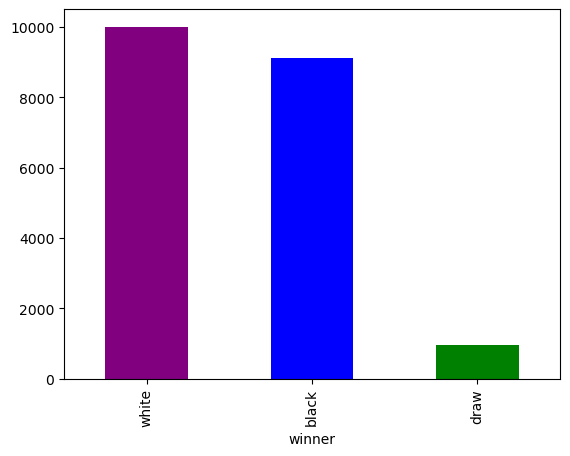

In [4]:
games['winner'].value_counts().plot(
    kind="bar",
    color=["purple","blue","green"]
)


Task 3

The white_rating column is an integer column
This single continuous scale value is best displayed on a histogram


<Axes: ylabel='Frequency'>

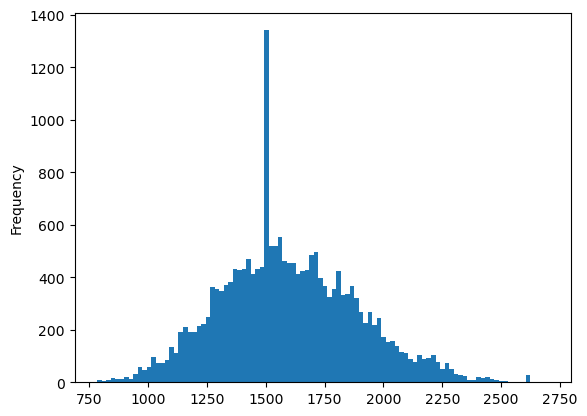

In [7]:
games['white_rating'].plot(kind="hist", bins= 100)

### Task 4

Scatter Plots compare two numerical columns

The pattern slopes up, indicating that there is a positive correlation between the ratings of players in a given match.

<Axes: xlabel='white_rating', ylabel='black_rating'>

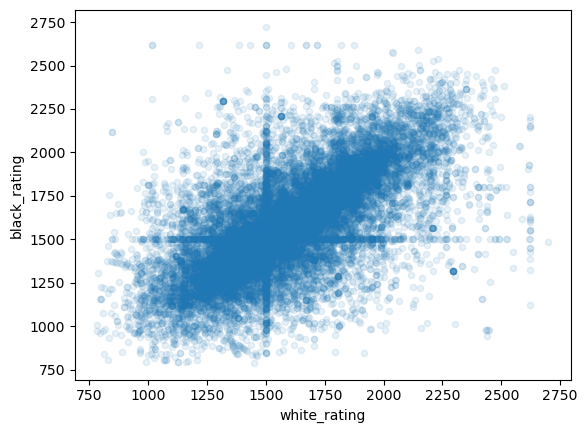

In [8]:
games.plot(kind="scatter", x="white_rating", y="black_rating", alpha=0.1)

## Task 5

- The pattern shows a positive correlation between the two. They likely correlate, because the matchmaking system attempts to match players of similiar skill levels. So while they aren't directly causing the correlation, in a way they are indirectly causing eachother via the system.

## Task 6

- Turns is discrete, as you cannot have a half turn.
- You would want to use a histogram to group values, as there is a wide range of different values.

<Axes: ylabel='Frequency'>

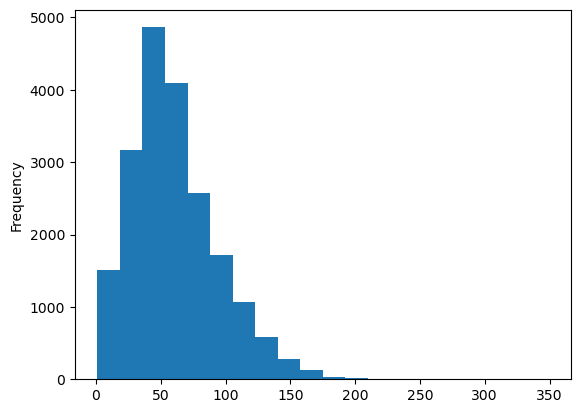

In [27]:
games["turns"].plot(kind="hist", bins=20)

## Task 7

- Draw is the longest ending on average, this isn't surprising, as you can only have a draw in chess when neither player has a move they can make.

In [10]:
avg_turns = games.groupby("victory_status")["turns"].mean()
avg_turns.sort_values(ascending=False)

victory_status
draw         83.781457
outoftime    72.742857
mate         65.415020
resign       53.912533
Name: turns, dtype: float64

## Task 8

- A line chart fits time data, and you wouldn't want to use a bar chart as it won't show relationships over time.

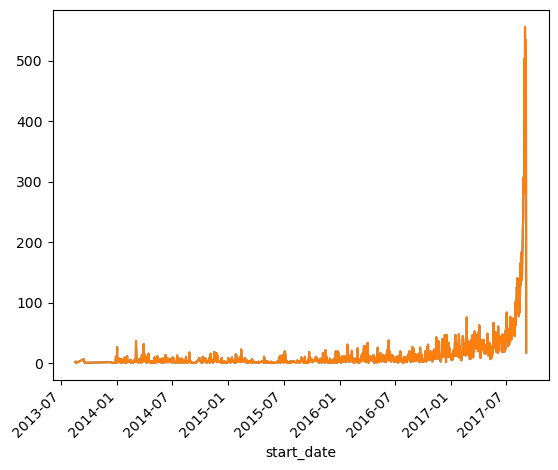

In [17]:
games["start_date"] = pd.to_datetime(
    games["created_at"], unit="ms"
)

daily = games["start_date"].dt.date.value_counts().sort_index()
daily.plot(kind="line")

import matplotlib.pyplot as plt

games["start_date"] = pd.to_datetime(games["created_at"], unit="ms")

daily = games["start_date"].dt.date.value_counts().sort_index()

daily.plot(kind="line")

plt.xticks(rotation=45, ha='right')

plt.show()

## Task 9

- Horizontal Bar Charts are easier to read with long labels as they won't bleed into eachother.

<Axes: title={'center': 'Top 10 Most Common Openings'}, xlabel='Number of Games', ylabel='opening_name'>

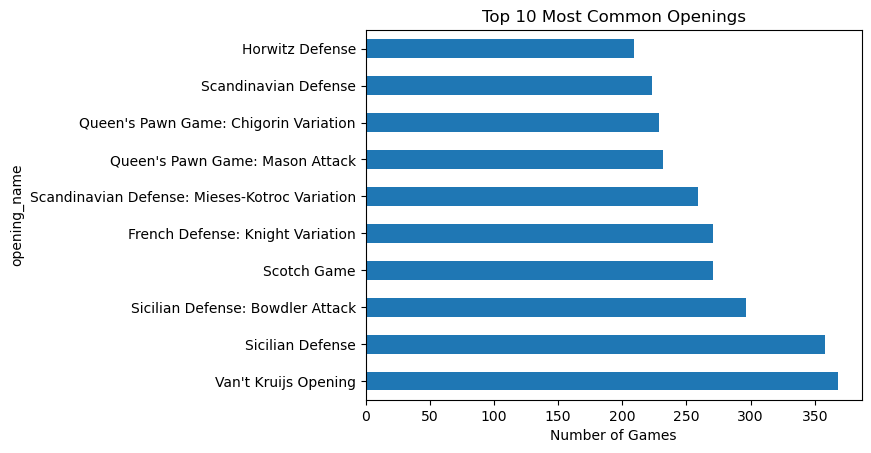

In [12]:
top_openings = games["opening_name"].value_counts().head(10)
top_openings.plot(kind="barh", xlabel="Number of Games", title="Top 10 Most Common Openings")

## Task 10

- It would become a Spatial datatype
- Bar charts can't show geographic relationships like a map could.
- GeoPandas or Plotly are libraries that could handle this better

In [ ]:
ag = pd.read_csv("2011_ag.csv")
ag.head()

## Task 11

- Task 6's Histogram had fewer outliers, however, overall they share a trend.

<Axes: title={'center': 'Game Length for White Ratings 2000+'}, ylabel='Frequency'>

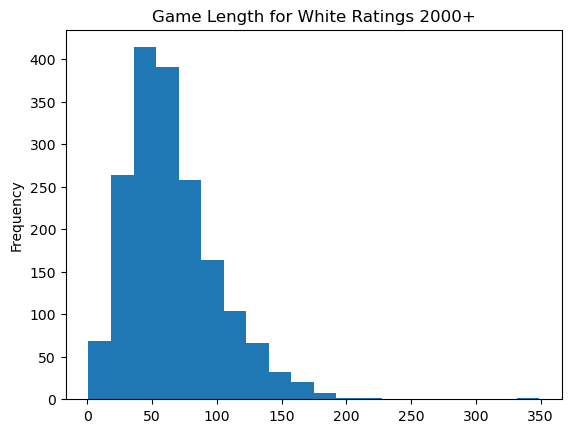

In [25]:
above_2k = games[games["white_rating"] > 2000]
above_2k.sort_values("white_rating")["white_rating"]
above_2k["turns"].plot(kind="hist", bins=20, title="Game Length for White Ratings 2000+")

## Task 12

<Axes: title={'center': 'Rating Distribution: White vs. Black'}, xlabel='Player Rating', ylabel='Frequency'>

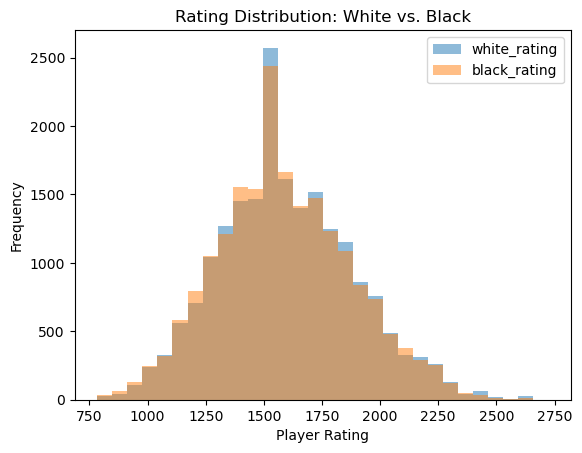

In [28]:
games[["white_rating", "black_rating"]].plot(
    kind="hist",
    bins=30,
    alpha=0.5,
    title="Rating Distribution: White vs. Black",
    xlabel="Player Rating",
)

In [29]:
games.describe()

,created_at,last_move_at,turns,white_rating,black_rating,opening_ply,start_date
count,2.005800e+04,2.005800e+04,20058.000000,20058.000000,20058.000000,20058.000000,20058
mean,1.483617e+12,1.483618e+12,60.465999,1596.631868,1588.831987,4.816981,2017-01-05 11:47:32.629092352
min,1.376772e+12,1.376772e+12,1.000000,784.000000,789.000000,1.000000,2013-08-17 20:33:53.173000
25%,1.477548e+12,1.477548e+12,37.000000,1398.000000,1391.000000,3.000000,2016-10-27 05:51:40
50%,1.496010e+12,1.496010e+12,55.000000,1567.000000,1562.000000,4.000000,2017-05-28 22:20:00
75%,1.503170e+12,1.503170e+12,79.000000,1793.000000,1784.000000,6.000000,2017-08-19 19:13:20
max,1.504493e+12,1.504494e+12,349.000000,2700.000000,2723.000000,28.000000,2017-09-04 02:45:43.790000
std,2.850151e+10,2.850140e+10,33.570585,291.253376,291.036126,2.797152,NaN


## Task 13

- Opening moves clearly answers a question someone might have about the data. It's pertinent information for understanding the game, but it's also information that's harder to intuit, compared to white v. black win rate, which has an easier to perceive advantage.

- Opening moves would also have been information you couldn't have pulled from .describe(). As it was layered information, requiring the 